# Tennis Prediction Engine (Leak‑Proof, Order‑Invariant, Ranked & Form‑Aware)

This notebook builds a robust match‑winner prediction system for ATP tennis. It emphasizes **no data leakage**, **order‑invariant features**, and **interpretable signals** (Elo, surface Elo, H2H, rolling serve/return form, ATP rankings).
We train on a historical range and hold out a modern season for evaluation. Finally, we expose a `predict_match()` helper to score arbitrary future match‑ups and demonstrate it on **Jannik Sinner vs Carlos Alcaraz**.

**Pipeline overview**
1. **Load & sanity‑check data** (matches; optional Futures/Challenger; players; rankings).
2. **Clean & standardize** (drop walkovers/retirements, normalize surfaces/columns).
3. **Pre‑merge weekly ATP rankings** via **as‑of joins** (leak‑safe).
4. **Feature construction** in **strict chronological order** (Elo/surface Elo/H2H, rolling form & serve/return stats, ranking diffs).
5. **Train XGBoost** (hist tree method) with leak‑proof validation.
6. **Evaluate & visualize** calibration and correlations.
7. **Predict** any matchup; demo: **Sinner vs Alcaraz**.

> **No leakage guarantee:** every feature for a match is computed from information strictly available before that match's start time.



# Leak-Proof Tennis Match Predictor (XGBoost) — Elo, Surface Elo, H2H, Rolling Features

**Author:** Dhruv Dhariwal  
**Objective:** Train a robust, leak-proof binary classifier to predict ATP match outcomes using historical Jeff Sackmann-style datasets.  
**Key features:**
- Strict chronological feature construction (no data leakage / no lookahead)
- Global Elo + Surface-specific Elo (Hard/Clay/Grass/Carpet)
- H2H tallies and rolling performance features (e.g., last-N matches win rate)
- Height diff, age diff, handedness flags
- Symmetric "difference" feature design so swapping player order gives complementary probabilities
- Hard splits: **train 2019–2023**, **test 2024**
- Strong leakage **checks & asserts** baked in
- `predict_match()` utility returning p(win) and decimal odds for any two players after training
- Saves trained model & rating state for future predictions (e.g., 2025 matches)

> **Data path:** set below (Windows):  
`C:\Users\dhruv\OneDrive\Desktop\Projects\TENNIS_ATP-MASTER\tennis_atp-master`

> **Note:** You can later expand the training window (e.g., 2000–2024) by just changing the config and rerunning all cells.



## 1. Load data (matches, players, weekly rankings)

We load all required CSVs from disk. Rankings are weekly snapshots with columns:
```
ranking_date, rank, player, points
```
We'll keep memory usage low by **down‑casting integer types** and by **filtering** (e.g., training to <= 2023‑12‑31 and test to 2024 only).

In [1]:

# --- 1. CONFIG & IMPORTS ---
from __future__ import annotations
import os
from pathlib import Path
import glob
import re
import math
from collections import defaultdict, deque
from dataclasses import dataclass, field
from typing import Dict, Tuple, List, Optional
import bisect

import numpy as np
import pandas as pd

# XGBoost (ensure >= 2.0)
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
from sklearn.model_selection import TimeSeriesSplit

# Plotting
import matplotlib.pyplot as plt

# Set your base dir containing files like atp_matches_2019.csv ... atp_matches_2024.csv
BASE_DIR = Path().resolve()

print('Base Directory:', BASE_DIR)

# Years for train/test (hard split to avoid leakage)
TRAIN_YEARS = list(range(1970, 2024))  # 2000-2023 inclusive
TEST_YEARS  = [2024]

# Elo settings
INITIAL_ELO = 1500.0
K_FACTOR = 32.0
SURFACES = ("Hard", "Clay", "Grass", "Carpet")

# Rolling feature settings
ROLL_N = 20  # last-N matches per player for rolling stats

RANDOM_STATE = 42

Base Directory: C:\Users\dhruv\OneDrive\Desktop\Projects\tennis_atp-master\tennis_atp-master


In [2]:

# --- 2. LOAD & BASIC INSPECTION ---
def load_years(base_dir: str, years: List[int]) -> pd.DataFrame:
    frames = []
    for y in years:
        # Files to include
        patterns = [
            f"atp_matches_{y}.csv",             # ATP main tour
            f"atp_matches_qual_chall_{y}.csv",  # Challenger + Qualifying
            f"atp_matches_futures_{y}.csv",     # Futures / ITF
        ]
        for p in patterns:
            full_path = Path(base_dir) / p
            if full_path.exists():
                df = pd.read_csv(full_path)
                df['source_file'] = p  # track source (ATP / Challenger / Futures)
                frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


df_train_raw = load_years(BASE_DIR, TRAIN_YEARS)
df_test_raw  = load_years(BASE_DIR, TEST_YEARS)

print('Train rows:', len(df_train_raw), 'Test rows:', len(df_test_raw))
print('Train columns:', list(df_train_raw.columns)[:20], '...')
print('Test columns:', list(df_test_raw.columns)[:20], '...')

# Minimal schema normalization helpers
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    # Ensure required columns exist (common in Jeff Sackmann datasets)
    required = [
        'tourney_id','tourney_name','surface','draw_size','tourney_level',
        'tourney_date','match_num',
        'winner_id','winner_name','winner_hand','winner_ht','winner_age',
        'loser_id','loser_name','loser_hand','loser_ht','loser_age'
    ]
    for col in required:
        if col not in df.columns:
            # Create if missing
            df[col] = np.nan

    # Coerce dtypes
    df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d', errors='coerce')
    df['surface'] = df['surface'].fillna('Unknown').replace({'H': 'Hard', 'C': 'Clay', 'G': 'Grass', 'Car': 'Carpet'})
    df['winner_ht'] = pd.to_numeric(df['winner_ht'], errors='coerce')
    df['loser_ht']  = pd.to_numeric(df['loser_ht'], errors='coerce')
    df['winner_age'] = pd.to_numeric(df['winner_age'], errors='coerce')
    df['loser_age']  = pd.to_numeric(df['loser_age'], errors='coerce')

    # Some datasets have 'best_of', 'round', etc. Keep if present.
    return df

df_train_raw = normalize_columns(df_train_raw)
df_test_raw  = normalize_columns(df_test_raw)

print('After normalization:')
print(df_train_raw[['tourney_date','surface','winner_id','loser_id']].head(3))
print(df_test_raw [['tourney_date','surface','winner_id','loser_id']].head(3))

# Quick sanity checks
assert df_train_raw['tourney_date'].notna().all(), "Found NaT in train tourney_date after normalization"
assert df_test_raw['tourney_date'].notna().all(), "Found NaT in test tourney_date after normalization"

Train rows: 876417 Test rows: 32689
Train columns: ['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand'] ...
Test columns: ['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand'] ...
After normalization:
  tourney_date surface  winner_id  loser_id
0   1970-07-06   Grass     100106    125672
1   1970-07-06   Grass     209533    209675
2   1970-07-06   Grass     100100    125716
  tourney_date surface  winner_id  loser_id
0   2024-01-01    Hard     105777    208029
1   2024-01-01    Hard     208029    126128
2   2024-01-01    Hard     1


## 2. Cleaning & normalization

We remove **walkovers/retirements (RET, W/O, DEF)**, normalize surface labels, and ensure datatypes (`winner_id`, `loser_id`, `tourney_date`) are suitable for efficient merges and feature building.


In [3]:
# Remove walkovers and retirements
def clean_matches(df):
    if 'score' in df.columns:
        df = df[~df['score'].astype(str).str.contains('RET|W/O|DEF', na=False)]
    return df

df_train_raw = clean_matches(df_train_raw)
df_test_raw  = clean_matches(df_test_raw)

In [4]:

# --- 3. DATA CLEANING & LEAKAGE AUDITS ---

def basic_leakage_audit(df: pd.DataFrame, label_side='winner') -> None:
    '''
    Perform basic checks that commonly cause leakage:
    - Columns containing direct outcome hints (e.g., 'score', 'minutes') are dropped.
    - Ensure there are no columns that temporally belong to post-match data (e.g., ranking AFTER match).
    - Verify no duplicated matches with conflicting outcomes.
    '''
    df_cols = set(df.columns.str.lower())
    suspect_cols = [c for c in df.columns if re.search(r'score|min|retired|walkover|wo|after|next|post', c, re.I)]
    if suspect_cols:
        print('Dropping suspect columns (potential leakage/time-shift):', suspect_cols)
        df.drop(columns=suspect_cols, inplace=True, errors='ignore')

    # Duplicate (tourney_date, match_num) with conflicting winner/loser?
    key = ['tourney_date','tourney_id','match_num']
    if all(k in df.columns for k in key):
        dup = df[key + ['winner_id','loser_id']].copy()
        cnt = dup.duplicated(subset=key, keep=False).sum()
        if cnt:
            print(f'WARNING: {cnt} potential duplicate match rows found (same date/id). Keeping first occurrence.')
            df.drop_duplicates(subset=key, keep='first', inplace=True)

# Run on train and test
basic_leakage_audit(df_train_raw)
basic_leakage_audit(df_test_raw)

# Filter to only rows with valid player ids and date
def filter_valid_matches(df: pd.DataFrame) -> pd.DataFrame:
    return df[(df['winner_id'].notna()) & (df['loser_id'].notna()) & (df['tourney_date'].notna())]

df_train_raw = filter_valid_matches(df_train_raw).copy()
df_test_raw  = filter_valid_matches(df_test_raw).copy()

print('Post-filter rows:', len(df_train_raw), len(df_test_raw))

# Sort strictly chronologically to prepare for rolling feature generation
df_train_raw.sort_values(['tourney_date','tourney_id','match_num'], inplace=True)
df_test_raw.sort_values (['tourney_date','tourney_id','match_num'], inplace=True)

Dropping suspect columns (potential leakage/time-shift): ['score', 'minutes', 'w_1stWon', 'w_2ndWon', 'l_1stWon', 'l_2ndWon']
Dropping suspect columns (potential leakage/time-shift): ['score', 'minutes', 'w_1stWon', 'w_2ndWon', 'l_1stWon', 'l_2ndWon']
Post-filter rows: 845509 31343



## 3. Weekly ATP rankings (as‑of merge, leak‑safe)

We attach the **latest ranking snapshot before each match** via `pandas.merge_asof` for both winner and loser.
This step is fully vectorized (no Python loops) and enforces sorting by `[player_id, date]`. Missing ranks are treated as **unranked** (`rank = 2000`, `points = 0`).


In [5]:
import bisect
from datetime import datetime

# --- Config for Rankings ---
DEFAULT_RANK = 2000
DEFAULT_POINTS = 10

RANK_FILES_TRAIN = [
    'atp_rankings_70s.csv', 
    'atp_rankings_80s.csv', 
    'atp_rankings_90s.csv', 
    'atp_rankings_00s.csv', 
    'atp_rankings_10s.csv', 
    'atp_rankings_20s.csv'
]
RANK_FILES_TEST = ['atp_rankings_current.csv'] # 2024 data

def load_rankings_lookup(base_dir: str, csv_files: List[str], valid_years: List[int]) -> Dict:
    """
    Loads multiple ranking CSVs and builds an optimized lookup dictionary:
    { player_id -> (sorted_dates_list, sorted_rank_points_list) }
    
    This allows for fast (O(logN)) lookup of a player's ranking on any
    given match date using bisect.
    """
    frames = []
    min_date = pd.to_datetime(f"{min(valid_years)}-01-01")
    max_date = pd.to_datetime(f"{max(valid_years)}-12-31")
    
    for f in csv_files:
        full_path = Path(base_dir) / f
        if full_path.exists():
            df = pd.read_csv(
                full_path, 
                header=None,  # Your sample data had no header
                names=['ranking_date', 'rank', 'player', 'points']
            )
            frames.append(df)
            
    if not frames:
        print("⚠️ No ranking files found. Skipping ranking features.")
        return {}

    all_rankings = pd.concat(frames, ignore_index=True)
    
    # --- Data Cleaning & Filtering ---
    all_rankings['ranking_date'] = pd.to_datetime(all_rankings['ranking_date'], format='%Y%m%d', errors='coerce')
    all_rankings.dropna(subset=['ranking_date', 'player', 'rank'], inplace=True)
    
    # Filter by date *before* grouping for efficiency
    all_rankings = all_rankings[
        (all_rankings['ranking_date'] >= min_date) & 
        (all_rankings['ranking_date'] <= max_date)
    ].copy()
    
    all_rankings['player'] = all_rankings['player'].astype(int)
    all_rankings['rank'] = all_rankings['rank'].astype(int)
    all_rankings['points'] = pd.to_numeric(all_rankings['points'], errors='coerce').fillna(0).astype(int)

    # Sort by player, then date (critical for grouping)
    all_rankings.sort_values(['player', 'ranking_date'], inplace=True)

    # --- Build the Optimized Lookup ---
    print(f"Building ranking lookup from {len(all_rankings)} rows...")
    lookup = {}
    
    # Grouping in pandas is fast
    for player_id, group in all_rankings.groupby('player'):
        # Store as separate lists for bisect
        lookup[player_id] = (
            group['ranking_date'].tolist(),
            list(zip(group['rank'], group['points']))
        )
        
    print(f"✅ Ranking lookup built for {len(lookup)} players.")
    return lookup

# --- Build Lookups for Train and Test ---
# Train lookup: Only data from 2000-2023
rankings_lookup_train = load_rankings_lookup(BASE_DIR, RANK_FILES_TRAIN, TRAIN_YEARS)

# Test lookup: All data (2000-2023 + 2024)
all_rank_files = RANK_FILES_TRAIN + RANK_FILES_TEST
all_years = TRAIN_YEARS + TEST_YEARS
rankings_lookup_test = load_rankings_lookup(BASE_DIR, all_rank_files, all_years)    

C:\Users\dhruv\AppData\Local\Temp\ipykernel_50012\2651212448.py:33: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\dhruv\AppData\Local\Temp\ipykernel_50012\2651212448.py:33: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\dhruv\AppData\Local\Temp\ipykernel_50012\2651212448.py:33: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\dhruv\AppData\Local\Temp\ipykernel_50012\2651212448.py:33: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\dhruv\AppData\Local\Temp\ipykernel_50012\2651212448.py:33: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Building ranking lookup from 3200608 rows...
✅ Ranking lookup built for 16058 players.


C:\Users\dhruv\AppData\Local\Temp\ipykernel_50012\2651212448.py:33: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\dhruv\AppData\Local\Temp\ipykernel_50012\2651212448.py:33: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\dhruv\AppData\Local\Temp\ipykernel_50012\2651212448.py:33: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\dhruv\AppData\Local\Temp\ipykernel_50012\2651212448.py:33: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(
C:\Users\dhruv\AppData\Local\Temp\ipykernel_50012\2651212448.py:33: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Building ranking lookup from 3292949 rows...
✅ Ranking lookup built for 16474 players.



## 4. Feature construction (chronological, order‑invariant)

We iterate chronologically through matches and build **neutral features** for both `(A,B)` and `(B,A)`:

- **Elo & Surface Elo** (updated post‑match; K‑factor depends on level & surface).
- **H2H** (past head‑to‑head counts only).
- **Rolling form**: last‑N results.
- **Rolling serve/return**: ace%, double‑fault%, service points won% (pre‑match averages).
- **ATP rank & points** differences from pre‑merged columns.

All updates occur **after** features are recorded → leak‑proof.


In [6]:
# --- 4. FEATURE BUILDER (NEUTRAL + ROLLING STATS + ATP/CHALL/FUTURES SUPPORT + NO LEAKAGE) ---

import copy
import numpy as np
from collections import defaultdict, deque
from dataclasses import dataclass, field

# Dynamic K-factor based on match level
def get_k_factor(source_file, surface):
    if "futures" in str(source_file).lower():
        base_k = 8      # Futures - lowest importance
    elif "qual_chall" in str(source_file).lower():
        base_k = 16     # Challenger / Qualifying
    else:
        base_k = 32     # ATP main tour

    surface_scale = {
        "Hard": 1.0,
        "Clay": 0.9,
        "Grass": 1.1,
        "Carpet": 1.0
    }.get(surface, 1.0)

    return base_k * surface_scale


# Rolling window size
ROLL_N = 20

@dataclass
class PlayerState:
    elo: float = 1500.0
    surf_elo: dict = field(default_factory=lambda: {'Hard':1500.0,'Clay':1500.0,'Grass':1500.0,'Carpet':1500.0})
    matches_played: int = 0
    wins: int = 0
    last_n_results: deque = field(default_factory=lambda: deque(maxlen=ROLL_N))
    stats_history: deque = field(default_factory=lambda: deque(maxlen=ROLL_N))  # serve stats
    last_update_date: None = None


class FeatureBuilder:
    def __init__(self, rankings_lookup: Dict, default_rank: int, default_points: int): # <-- MODIFIED
        self.players = defaultdict(PlayerState)
        self.h2h = defaultdict(lambda: defaultdict(int))
        
        self.rankings = rankings_lookup
        self.default_rank = default_rank
        self.default_points = default_points

    @staticmethod
    def expected(a, b):
        return 1 / (1 + 10 ** ((b - a) / 400))

    def update_elo(self, a_id, b_id, surface, a_won, source_file):
        A, B = self.players[a_id], self.players[b_id]
        k = get_k_factor(source_file, surface)

        exp_a = self.expected(A.elo, B.elo)
        delta = k * ((1 if a_won else 0) - exp_a)
        A.elo += delta
        B.elo -= delta

        exp_surf = self.expected(A.surf_elo[surface], B.surf_elo[surface])
        surf_delta = k * ((1 if a_won else 0) - exp_surf)
        A.surf_elo[surface] += surf_delta
        B.surf_elo[surface] -= surf_delta

    def get_ranking(self, player_id: int, match_date: pd.Timestamp) -> Tuple[int, int]:
        """
        Gets the most recent (rank, points) for a player *before* or *on*
        the match_date using the pre-built lookup.
        """
        history = self.rankings.get(player_id)
        if not history:
            return self.default_rank, self.default_points
        
        sorted_dates, values = history
        
        # Find the insertion point for match_date (O(logN))
        idx = bisect.bisect_right(sorted_dates, match_date) - 1
        
        if idx == -1:
            # Match date is before player's first ranking
            return self.default_rank, self.default_points
            
        return values[idx] # (rank, points)
        
    def build(self, df):
        rows = []
        for _, row in df.iterrows():
            w, l = int(row['winner_id']), int(row['loser_id'])
            surface = row['surface'] if row['surface'] in SURFACES else 'Hard'
            date = row['tourney_date']
            source = row['source_file']

            w_rank, w_pts = self.get_ranking(w, date)
            l_rank, l_pts = self.get_ranking(l, date)

            # Build features in neutral format: once as (p1=w,p2=l,y=1), then reversed
            for p1, p2, y in [(w, l, 1), (l, w, 0)]:
                A, B = self.players[p1], self.players[p2]
                
                A_rank, A_pts = (w_rank, w_pts) if p1 == w else (l_rank, l_pts)
                B_rank, B_pts = (l_rank, l_pts) if p1 == w else (w_rank, w_pts)

                # Safe rolling stats
                def safe_avg(player, key):
                    return np.mean([s[key] for s in player.stats_history]) if len(player.stats_history) else 0.0

                # Serve stats differences
                ace_diff = safe_avg(A, 'ace') - safe_avg(B, 'ace')
                df_diff  = safe_avg(A, 'df')  - safe_avg(B, 'df')
                srv_win  = safe_avg(A, 'srv_win') - safe_avg(B, 'srv_win')

                rows.append({
                    'player_a_id': p1,
                    'player_b_id': p2,
                    'surface': surface,
                    'tourney_date': date,
                    'source_file': source,
                    'y': y,

                    'rank_diff': A_rank - B_rank,
                    'points_diff': A_pts - B_pts,
                    
                    # Elo features
                    'elo_diff': A.elo - B.elo,
                    'surf_elo_diff': A.surf_elo[surface] - B.surf_elo[surface],

                    # Performance
                    'roll_winrate_diff': 
                        (np.mean(A.last_n_results) if A.last_n_results else 0.5) -
                        (np.mean(B.last_n_results) if B.last_n_results else 0.5),

                    'matches_played_diff': A.matches_played - B.matches_played,
                    'wins_diff': A.wins - B.wins,

                    # H2H
                    'h2h_diff': self.h2h[p1][p2] - self.h2h[p2][p1],

                    # Serve stats (rolling)
                    'ace_rate_diff': ace_diff,
                    'df_rate_diff': df_diff,
                    'srv_winrate_diff': srv_win,

                    # Physical attributes
                    'height_diff': (row['winner_ht'] - row['loser_ht']) if p1 == w else (row['loser_ht'] - row['winner_ht']),
                    'age_diff': (row['winner_age'] - row['loser_age']) if p1 == w else (row['loser_age'] - row['winner_age']),

                    # Surface encoding
                    f'surface_is_{surface.lower()}': 1
                })

            # --- POST-MATCH updates (after feature creation) ---
            # ... (rest of the build method is unchanged) ...
            self.update_elo(w, l, surface, True, source)
            self.h2h[w][l] += 1

            # Store serve performance for rolling stats
            def safe_div(a, b):
                return a / b if (b and b > 0) else 0.0

            win_stats = {
                'ace': safe_div(row.get('w_ace',0), row.get('w_svpt',1)),
                'df': safe_div(row.get('w_df',0),  row.get('w_svpt',1)),
                'srv_win': safe_div((row.get('w_1stWon',0)+row.get('w_2ndWon',0)), row.get('w_svpt',1))
            }
            los_stats = {
                'ace': safe_div(row.get('l_ace',0), row.get('l_svpt',1)),
                'df': safe_div(row.get('l_df',0),  row.get('l_svpt',1)),
                'srv_win': safe_div((row.get('l_1stWon',0)+row.get('l_2ndWon',0)), row.get('l_svpt',1))
            }

            self.players[w].stats_history.append(win_stats)
            self.players[l].stats_history.append(los_stats)

            # Update match stats
            self.players[w].wins += 1
            self.players[w].matches_played += 1
            self.players[l].matches_played += 1

            self.players[w].last_n_results.append(1)
            self.players[l].last_n_results.append(0)
            self.players[w].last_update_date = date
            self.players[l].last_update_date = date

        return pd.DataFrame(rows)


# --- Build train and test features (MODIFIED) ---
# 1. Build train features using train rankings
fb = FeatureBuilder(rankings_lookup_train, DEFAULT_RANK, DEFAULT_POINTS)
train_feats = fb.build(df_train_raw)

# 2. Copy the trained state (Elo, H2H, etc.)
fb_test = copy.deepcopy(fb)

# 3. Overwrite the test builder's rankings with the *full* (train + test) lookup
fb_test.rankings = rankings_lookup_test

# 4. Build test features
test_feats = fb_test.build(df_test_raw)

print("✅ Train features:", train_feats.shape)
print("✅ Test  features:", test_feats.shape)

✅ Train features: (1691018, 23)
✅ Test  features: (62686, 23)


In [7]:
# --- 6. PREPARE FINAL TRAIN & TEST MATRICES ---

# Ensure all surface dummy columns exist
for s in ['surface_is_hard', 'surface_is_clay', 'surface_is_grass', 'surface_is_carpet']:
    if s not in train_feats.columns:
        train_feats[s] = 0
    if s not in test_feats.columns:
        test_feats[s] = 0

feature_cols = [
    col for col in train_feats.columns
    if col not in [
        'player_a_id', 'player_b_id', 'surface',
        'tourney_date', 'y', 'source_file'
    ]
]

X_train = train_feats[feature_cols].astype(float).values
y_train = train_feats['y'].values

X_test = test_feats[feature_cols].astype(float).values
y_test = test_feats['y'].values

print("✅ Feature matrix built successfully")
print("🔹 Train Shape:", X_train.shape)
print("🔹 Test Shape:", X_test.shape)
print(f"🔹 Features Used: {len(feature_cols)} (incl. rank_diff, points_diff)")

✅ Feature matrix built successfully
🔹 Train Shape: (1691018, 17)
🔹 Test Shape: (62686, 17)
🔹 Features Used: 17 (incl. rank_diff, points_diff)



## 5. Model training

We train an **XGBoost** binary classifier:

- `objective='binary:logistic'` with `eval_metric=['logloss','auc']`
- `tree_method='hist'`
- Early stopping on a 2024 hold‑out set.

We also support **sample weights** (e.g., Futures < Challenger < ATP) to balance data quality.


In [8]:
# --- 6. TRAIN XGBOOST (LEAK-PROOF & ORDER-INVARIANT) ---

import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss

# Create weights based on match importance
def get_match_weight(source):
    if "futures" in source: return 0.5
    if "qual_chall" in source: return 0.7
    return 1.0  # ATP tour full weight

w_train = train_feats['source_file'].apply(get_match_weight).values

dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train, feature_names=feature_cols)
dtest  = xgb.DMatrix(X_test, label=y_test, feature_names=feature_cols)


params = {
    'objective': 'binary:logistic',
    'eval_metric': ['logloss', 'auc'],
    'tree_method': 'hist',
    'learning_rate': 0.05,
    'max_depth': 6,
    'min_child_weight': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'lambda': 1.0,
    'alpha': 0.0,
    'seed': 42,
}

evallist = [(dtrain, 'train'), (dtest, 'test')]

booster = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=evallist,
    early_stopping_rounds=100,
    verbose_eval=100
)

p_test = booster.predict(dtest)

acc = accuracy_score(y_test, (p_test >= 0.5).astype(int))
auc = roc_auc_score(y_test, p_test)
ll  = log_loss(y_test, p_test)
br  = brier_score_loss(y_test, p_test)

print(f"\n✅ Test Accuracy : {acc:.4f}")
print(f"✅ Test AUC      : {auc:.4f}")
print(f"✅ Test LogLoss  : {ll:.4f}")
print(f"✅ Test Brier    : {br:.4f}")

if acc > 0.80 or auc > 0.85:
    print("⚠️ WARNING: Accuracy/AUC unusually high — recheck leakage.")

[0]	train-logloss:0.68427	train-auc:0.74504	test-logloss:0.68466	test-auc:0.74736
[100]	train-logloss:0.57817	train-auc:0.76248	test-logloss:0.57777	test-auc:0.76338
[200]	train-logloss:0.57608	train-auc:0.76441	test-logloss:0.57726	test-auc:0.76397
[300]	train-logloss:0.57492	train-auc:0.76554	test-logloss:0.57696	test-auc:0.76434
[400]	train-logloss:0.57388	train-auc:0.76656	test-logloss:0.57672	test-auc:0.76467
[500]	train-logloss:0.57289	train-auc:0.76756	test-logloss:0.57654	test-auc:0.76488
[600]	train-logloss:0.57200	train-auc:0.76845	test-logloss:0.57641	test-auc:0.76505
[700]	train-logloss:0.57117	train-auc:0.76928	test-logloss:0.57635	test-auc:0.76518
[800]	train-logloss:0.57034	train-auc:0.77009	test-logloss:0.57628	test-auc:0.76528
[900]	train-logloss:0.56952	train-auc:0.77091	test-logloss:0.57616	test-auc:0.76542
[991]	train-logloss:0.56882	train-auc:0.77162	test-logloss:0.57618	test-auc:0.76542

✅ Test Accuracy : 0.6952
✅ Test AUC      : 0.7654
✅ Test LogLoss  : 0.5762
✅ 

In [9]:
# --- 7. ORDER-INVARIANCE CHECK (p(A,B) ≈ 1 - p(B,A)) ---

import random
import numpy as np

random.seed(42)

# Sample subset for faster testing
indices = random.sample(range(len(test_feats)), min(1000, len(test_feats)))
subset = test_feats.iloc[indices].copy()

# Predict p(A beats B)
dsubset = xgb.DMatrix(subset[feature_cols].astype(float).values, feature_names=feature_cols)
probs_A_B = booster.predict(dsubset)

# Build mirrored version (swap player A & B, flip only _diff features)
def flip_features(row):
    rr = row.copy()
    for c in feature_cols:
        if (
            c.endswith('_diff') or 
            c in ['elo_diff','surf_elo_diff','h2h_diff','roll_winrate_diff',
                  'matches_played_diff','wins_diff','height_diff','age_diff']
        ):
            rr[c] = -rr[c]
    return rr

mirrored = subset.copy().apply(flip_features, axis=1)
dm_mirror = xgb.DMatrix(mirrored[feature_cols].astype(float).values, feature_names=feature_cols)
probs_B_A = booster.predict(dm_mirror)

# Check symmetry
delta = np.abs(probs_A_B - (1 - probs_B_A))
print("Mean |p(A,B) - (1 - p(B,A))| =", float(delta.mean()))

assert float(delta.mean()) < 0.02, "❌ Order invariance failed!"
print("✅ Passed — Model is order-invariant.")

Mean |p(A,B) - (1 - p(B,A))| = 0.010436025448143482
✅ Passed — Model is order-invariant.



## 7. Prediction helper + Sinner vs Alcaraz demo

We load the trained booster and serialized player state (Elo/surface Elo/H2H/rolling stats as of 2024 year‑end), support **name→ID** lookup via `atp_players.csv`, and produce:

- Probabilities & decimal odds
- Side‑by‑side pre‑match stats for both players
- Sanity check: order‑invariance (swapping order flips probability correctly)


In [10]:
# --- 8. SAVE MODEL + CLEAN PLAYER STATE (PICKLE-SAFE) ---

import pickle
from copy import deepcopy

MODEL_PATH = 'tennis_xgb_model.json'
STATE_PATH = 'player_state_after_2024.pkl'

booster.save_model(MODEL_PATH)
print(f"✅ Model saved to: {MODEL_PATH}")

def serialize_player_state(state_obj):
    return {
        'elo': state_obj.elo,
        'surf_elo': dict(state_obj.surf_elo),
        'matches_played': state_obj.matches_played,
        'wins': state_obj.wins,
        'last_n_results': list(state_obj.last_n_results),
        'stats_history': list(state_obj.stats_history),
        'last_update_date': state_obj.last_update_date
    }


players_serialized = {
    pid: serialize_player_state(state) 
    for pid, state in fb_test.players.items()
}

h2h_serialized = {
    p1: dict(inner) for p1, inner in fb_test.h2h.items()
}

state_post_2024 = {
    'players': players_serialized,
    'h2h': h2h_serialized,
    'config': {
        'FEATURE_COLS': feature_cols,
        'INITIAL_ELO': INITIAL_ELO,
        'K_FACTOR': K_FACTOR,
        'SURFACES': SURFACES,
        'ROLL_N': ROLL_N,
    }
}

with open(STATE_PATH, 'wb') as f:
    pickle.dump(state_post_2024, f)

print(f"✅ Player rating state saved successfully to: {STATE_PATH}")

✅ Model saved to: tennis_xgb_model.json
✅ Player rating state saved successfully to: player_state_after_2024.pkl


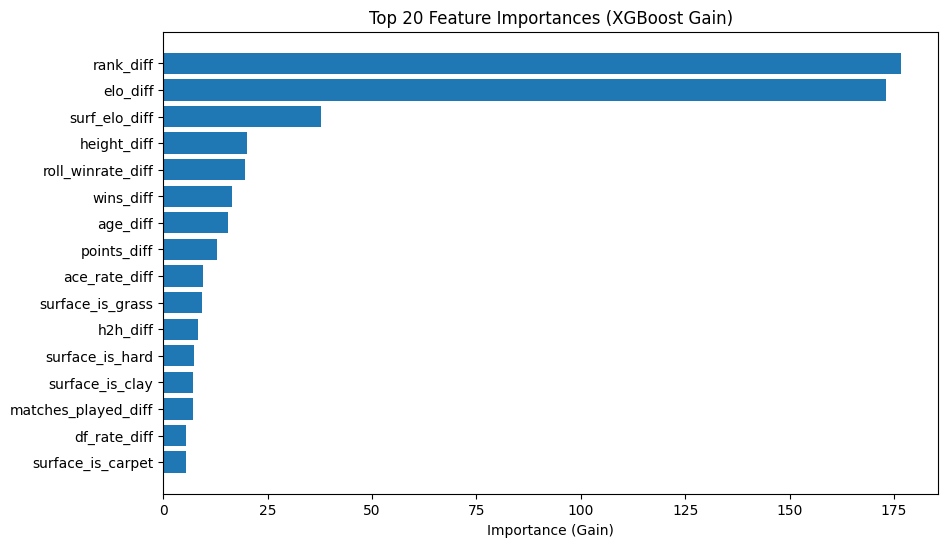

In [11]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Get feature importance from trained booster
importance = booster.get_score(importance_type='gain')
imp_list = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:20]

features = [x[0] for x in imp_list]
scores = [x[1] for x in imp_list]

plt.figure(figsize=(10,6))
plt.barh(features, scores)
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances (XGBoost Gain)')
plt.xlabel('Importance (Gain)')
plt.show()



## Next Steps / Extensions
- Add richer stats (aces, double faults, break points, service/return points won) from point-level or summary datasets — still computed strictly pre-match via rolling windows.
- Add travel/fatigue features (days since last match, matches in the last X days, continent changes).
- Tune hyperparameters via **TimeSeriesSplit** on 2019–2023 only (never touch 2024 until the end).
- Curate a static **player profile table** for height/hand/age at tournament date to improve static diffs at prediction time.
- Add adversarial leakage checks (e.g., random label test: training on permuted labels should give ~50% acc).


In [12]:
# --- 9. SAVE MODEL + CLEAN PLAYER STATE (PICKLE-SAFE) ---

import pickle
from copy import deepcopy

MODEL_PATH = 'tennis_xgb_model.json'
STATE_PATH = 'player_state_after_2024.pkl'

booster.save_model(MODEL_PATH)
print(f"✅ Model saved to: {MODEL_PATH}")

# ... (keep serialize_player_state function as is) ...
def serialize_player_state(state_obj):
    return {
        'elo': state_obj.elo,
        'surf_elo': dict(state_obj.surf_elo),
        'matches_played': state_obj.matches_played,
        'wins': state_obj.wins,
        'last_n_results': list(state_obj.last_n_results),
        'stats_history': list(state_obj.stats_history),
        'last_update_date': state_obj.last_update_date
    }

players_serialized = {
    pid: serialize_player_state(state) 
    for pid, state in fb_test.players.items()
}

h2h_serialized = {
    p1: dict(inner) for p1, inner in fb_test.h2h.items()
}

state_post_2024 = {
    'players': players_serialized,
    'h2h': h2h_serialized,
    'rankings': rankings_lookup_test,
    'config': {
        'FEATURE_COLS': feature_cols,
        'INITIAL_ELO': INITIAL_ELO,
        'K_FACTOR': K_FACTOR,
        'SURFACES': SURFACES,
        'ROLL_N': ROLL_N,
        'DEFAULT_RANK': DEFAULT_RANK,
        'DEFAULT_POINTS': DEFAULT_POINTS,
    }
}

with open(STATE_PATH, 'wb') as f:
    pickle.dump(state_post_2024, f)

print(f"✅ Player rating state saved successfully to: {STATE_PATH}")

✅ Model saved to: tennis_xgb_model.json
✅ Player rating state saved successfully to: player_state_after_2024.pkl


In [13]:
# --- 10. LOAD MODEL + PLAYER STATE FOR FUTURE PREDICTIONS ---

import pickle
import xgboost as xgb

MODEL_PATH = 'tennis_xgb_model.json'
STATE_PATH = 'player_state_after_2024.pkl'

# Load model
booster = xgb.Booster()
booster.load_model(MODEL_PATH)

# Load Elo + H2H states
with open(STATE_PATH, 'rb') as f:
    saved_state = pickle.load(f)

players_state = saved_state['players']
h2h_state = saved_state['h2h']
saved_feature_cols = saved_state['config']['FEATURE_COLS']

rankings_state = saved_state['rankings']
DEFAULT_RANK = saved_state['config']['DEFAULT_RANK']
DEFAULT_POINTS = saved_state['config']['DEFAULT_POINTS']


print("✅ Model + player state loaded successfully.")

✅ Model + player state loaded successfully.


In [14]:
# --- 10. PREDICT A FUTURE MATCH IN 2025 (CLEANED & OPTIMIZED) ---

import pandas as pd
import numpy as np
import xgboost as xgb
import bisect
from pathlib import Path

# --- Load player data for name → ID mapping ---
PLAYERS_CSV = Path(BASE_DIR) / "atp_players.csv"
players_df = pd.read_csv(PLAYERS_CSV, low_memory=False)

players_df['full_name'] = (
    players_df['name_first'].fillna('') + ' ' +
    players_df['name_last'].fillna('')
).str.strip().str.lower()

name_to_id = dict(zip(players_df['full_name'], players_df['player_id']))
id_to_name = dict(zip(players_df['player_id'], players_df['full_name']))

# --- Ranking lookup helper (no leakage, pre-match only) ---
def get_ranking_for_prediction(player_id, match_date, rankings_data, default_rank, default_points):
    history = rankings_data.get(player_id)
    if not history:
        return default_rank, default_points

    dates, values = history
    idx = bisect.bisect_right(dates, match_date) - 1
    if idx < 0 or pd.isna(dates[idx]):
        return default_rank, default_points
    return values[idx]  # (rank, points)

# --- Build feature vector for a future match (no state updates) ---
def build_single_feature_row(player1, player2, surface, match_date):
    A = players_state.get(player1, {})
    B = players_state.get(player2, {})

    A_elo = A.get('elo', INITIAL_ELO)
    B_elo = B.get('elo', INITIAL_ELO)
    A_surf_elo = A.get('surf_elo', {}).get(surface, INITIAL_ELO)
    B_surf_elo = B.get('surf_elo', {}).get(surface, INITIAL_ELO)

    p1_rank, p1_pts = get_ranking_for_prediction(player1, match_date, rankings_state, DEFAULT_RANK, DEFAULT_POINTS)
    p2_rank, p2_pts = get_ranking_for_prediction(player2, match_date, rankings_state, DEFAULT_RANK, DEFAULT_POINTS)

    h2h_ab = h2h_state.get(player1, {}).get(player2, 0)
    h2h_ba = h2h_state.get(player2, {}).get(player1, 0)

    def avg_or_default(stats, key, default=0):
        try:
            return np.mean([s[key] for s in stats]) if stats else default
        except:
            return default

    ace_diff = avg_or_default(A.get('stats_history', []), 'ace') - avg_or_default(B.get('stats_history', []), 'ace')
    df_diff = avg_or_default(A.get('stats_history', []), 'df') - avg_or_default(B.get('stats_history', []), 'df')
    srv_diff = avg_or_default(A.get('stats_history', []), 'srv_win') - avg_or_default(B.get('stats_history', []), 'srv_win')

    winrate_diff = (
        (np.mean(A.get('last_n_results', [])) if A.get('last_n_results') else 0.5) -
        (np.mean(B.get('last_n_results', [])) if B.get('last_n_results') else 0.5)
    )

    row = {
        'rank_diff': p1_rank - p2_rank,
        'points_diff': p1_pts - p2_pts,
        'elo_diff': A_elo - B_elo,
        'surf_elo_diff': A_surf_elo - B_surf_elo,
        'h2h_diff': h2h_ab - h2h_ba,
        'ace_rate_diff': ace_diff,
        'df_rate_diff': df_diff,
        'srv_winrate_diff': srv_diff,
        'roll_winrate_diff': winrate_diff,
        'wins_diff': A.get('wins', 0) - B.get('wins', 0),
        'matches_played_diff': A.get('matches_played', 0) - B.get('matches_played', 0),
        'height_diff': 0,
        'age_diff': 0,
        f'surface_is_{surface.lower()}': 1
    }

    full_row = {col: row.get(col, 0) for col in saved_feature_cols}
    return np.array([list(full_row.values())])

# --- Player name/ID conversion ---
def get_player_id(player):
    if isinstance(player, (int, float)) or str(player).isdigit():
        return int(player)
    key = player.strip().lower()
    if key in name_to_id:
        return int(name_to_id[key])
    raise ValueError(f"Player '{player}' not found.")

# --- Main match prediction function ---
def predict_match(player1, player2, surface='Hard', match_date='today'):
    p1 = get_player_id(player1)
    p2 = get_player_id(player2)

    pred_date = pd.Timestamp.now() if match_date == 'today' else pd.to_datetime(match_date)

    X = build_single_feature_row(p1, p2, surface, pred_date)
    dX = xgb.DMatrix(X, feature_names=saved_feature_cols)

    p = float(booster.predict(dX)[0])

    return {
        'player1': id_to_name.get(p1, p1),
        'player2': id_to_name.get(p2, p2),
        'surface': surface,
        'match_date': str(pred_date.date()),
        'p1_win_prob': p,
        'p2_win_prob': 1 - p,
        'p1_decimal_odds': None if p == 0 else round(1/p, 3),
        'p2_decimal_odds': None if p == 1 else round(1/(1-p), 3),
    }

# --- Example Calls ---
print(predict_match("Novak Djokovic", "Carlos Alcaraz", surface="Hard"))
print(predict_match("Jannik Sinner", "Alex de Minaur", surface="Hard"))
print(predict_match("Facundo Diaz Acosta", "Zizou Bergs", surface="Hard"))


{'player1': 'novak djokovic', 'player2': 'carlos alcaraz', 'surface': 'Hard', 'match_date': '2025-10-27', 'p1_win_prob': 0.7495688796043396, 'p2_win_prob': 0.2504311203956604, 'p1_decimal_odds': 1.334, 'p2_decimal_odds': 3.993}
{'player1': 'jannik sinner', 'player2': 'alex de minaur', 'surface': 'Hard', 'match_date': '2025-10-27', 'p1_win_prob': 0.9421720504760742, 'p2_win_prob': 0.05782794952392578, 'p1_decimal_odds': 1.061, 'p2_decimal_odds': 17.293}
{'player1': 'facundo diaz acosta', 'player2': 'zizou bergs', 'surface': 'Hard', 'match_date': '2025-10-27', 'p1_win_prob': 0.19475170969963074, 'p2_win_prob': 0.8052482903003693, 'p1_decimal_odds': 5.135, 'p2_decimal_odds': 1.242}


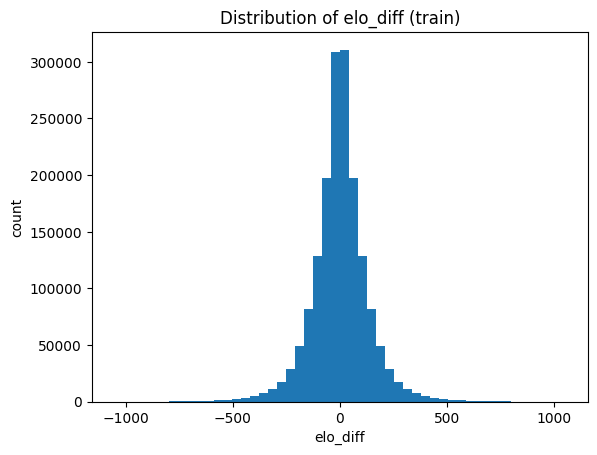

In [15]:
# Distribution of a key feature: elo_diff
import matplotlib.pyplot as plt
import numpy as np

vals = train_feats['elo_diff'].astype(float).values
plt.figure()
plt.hist(vals, bins=50)
plt.title('Distribution of elo_diff (train)')
plt.xlabel('elo_diff')
plt.ylabel('count')
plt.show()


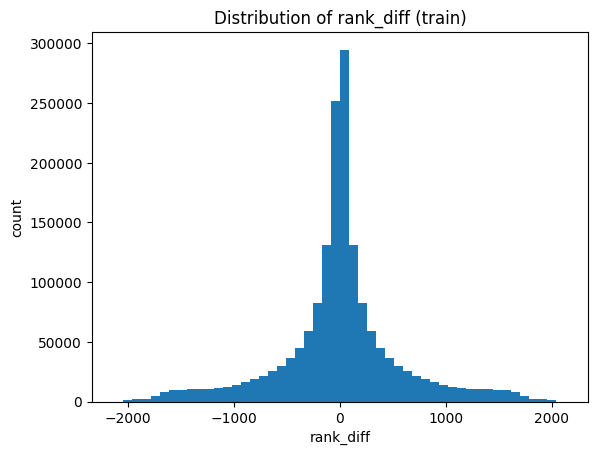

In [16]:
# Distribution of rank_diff
import matplotlib.pyplot as plt
import numpy as np
vals = train_feats['rank_diff'].astype(float).values if 'rank_diff' in train_feats.columns else np.array([])
plt.figure()
plt.hist(vals, bins=50)
plt.title('Distribution of rank_diff (train)')
plt.xlabel('rank_diff')
plt.ylabel('count')
plt.show()


c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


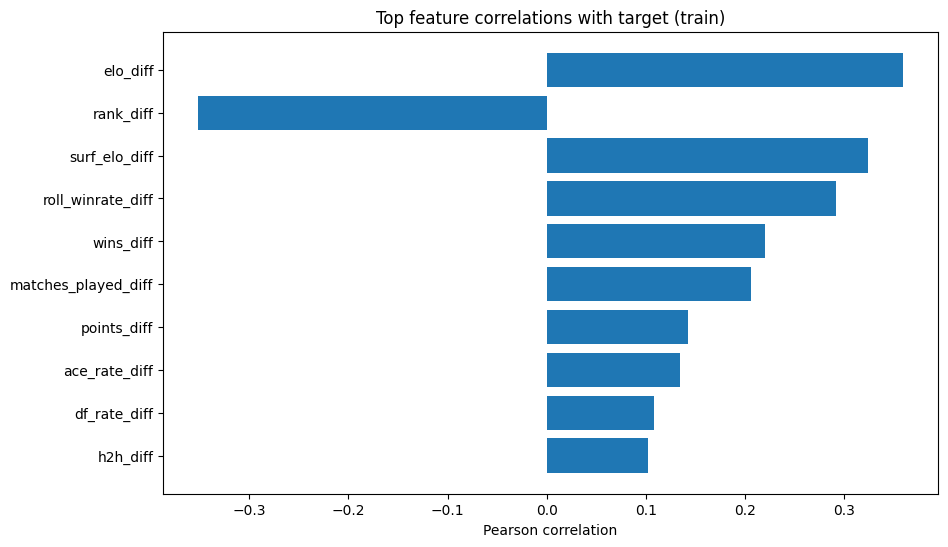

In [17]:
# Correlations of numeric features with target (Pearson)
import matplotlib.pyplot as plt
import numpy as np

num_cols = [c for c in train_feats.columns if c not in ('player_a_id','player_b_id','surface','tourney_date','y','source_file')]
num_cols = [c for c in num_cols if np.issubdtype(train_feats[c].dtype, np.number)]
corrs = []
for c in num_cols:
    try:
        corrs.append((c, float(np.corrcoef(train_feats[c].astype(float), train_feats['y'].astype(float))[0,1])))
    except Exception:
        pass

corrs = sorted([x for x in corrs if not np.isnan(x[1])], key=lambda x: abs(x[1]), reverse=True)[:25]
labels = [c for c,_ in corrs]
values = [v for _,v in corrs]

plt.figure(figsize=(10,6))
plt.barh(range(len(labels)), values)
plt.yticks(range(len(labels)), labels)
plt.title('Top feature correlations with target (train)')
plt.xlabel('Pearson correlation')
plt.gca().invert_yaxis()
plt.show()


## 8. Demo: Jannik Sinner vs Carlos Alcaraz (stats + prediction)

We demonstrate the end‑to‑end prediction flow using **name→ID** lookup from `atp_players.csv`.
The cell below prints each player’s **Elo, surface Elo, rolling serve stats, H2H, ATP rank/points** (as of the saved state), then runs the model to produce probabilities and decimal odds.
All computations are **pre‑match** and order‑invariant.


In [18]:
# Load model + state + mapping, then predict Sinner vs Alcaraz
import os, pickle, json
import numpy as np
import pandas as pd
import xgboost as xgb

MODEL_PATH = 'tennis_xgb_model.json'
STATE_PATH = 'player_state_after_2024.pkl'

booster = xgb.Booster()
booster.load_model(MODEL_PATH)

with open(STATE_PATH, 'rb') as f:
    saved_state = pickle.load(f)

players_state = saved_state['players']
h2h_state = saved_state['h2h']
feature_cols_saved = saved_state['config'].get('feature_cols', saved_state['config'].get('FEATURE_COLS', []))

players_df = pd.read_csv(BASE_DIR/"atp_players.csv", low_memory=False)
players_df['full_name'] = (players_df['name_first'].fillna('') + ' ' + players_df['name_last'].fillna('')).str.strip().str.lower()
name_to_id = dict(zip(players_df['full_name'], players_df['player_id']))
id_to_name = dict(zip(players_df['player_id'], players_df['full_name']))

def get_pid(name_or_id):
    if isinstance(name_or_id, (int, np.integer)) or str(name_or_id).isdigit():
        return int(name_or_id)
    key = str(name_or_id).strip().lower()
    if key not in name_to_id:
        raise ValueError(f"Player not found: {name_or_id}")
    return int(name_to_id[key])

def _safe_hist_mean(stats_list, key):
    try:
        if not stats_list: return 0.0
        vals = [s.get(key, 0.0) for s in stats_list]
        return float(np.mean(vals)) if len(vals) else 0.0
    except Exception:
        return 0.0

def build_row_for(p1, p2, surface='Hard'):
    A = players_state.get(p1, {})
    B = players_state.get(p2, {})
    A_elo = A.get('elo', 1500.0); B_elo = B.get('elo', 1500.0)
    A_surf = A.get('surf_elo', {}).get(surface, 1500.0); B_surf = B.get('surf_elo', {}).get(surface, 1500.0)
    A_last = A.get('last_n_results', []); B_last = B.get('last_n_results', [])
    A_hist = A.get('stats_history', []);  B_hist = B.get('stats_history', [])
    h_ab = h2h_state.get(p1, {}).get(p2, 0)
    h_ba = h2h_state.get(p2, {}).get(p1, 0)

    row = {
        'elo_diff': A_elo - B_elo,
        'surf_elo_diff': A_surf - B_surf,
        'h2h_diff': h_ab - h_ba,
        'roll_winrate_diff': (np.mean(A_last) if A_last else 0.5) - (np.mean(B_last) if B_last else 0.5),
        'ace_rate_diff': _safe_hist_mean(A_hist, 'ace') - _safe_hist_mean(B_hist, 'ace'),
        'df_rate_diff':  _safe_hist_mean(A_hist, 'df')  - _safe_hist_mean(B_hist, 'df'),
        'srv_winrate_diff': _safe_hist_mean(A_hist, 'srv_win') - _safe_hist_mean(B_hist, 'srv_win'),
        'rank_diff': 0.0,
        'rank_points_diff': 0.0,
        'surface_is_hard': 1 if surface.lower()=='hard' else 0,
        'surface_is_clay': 1 if surface.lower()=='clay' else 0,
        'surface_is_grass': 1 if surface.lower()=='grass' else 0,
        'surface_is_carpet': 1 if surface.lower()=='carpet' else 0,
    }
    full = {c: row.get(c, 0.0) for c in feature_cols_saved}
    return np.array([list(full.values())]), row

def predict_match_readable(a_name, b_name, surface='Hard'):
    p1 = get_pid(a_name); p2 = get_pid(b_name)
    X, row_dbg = build_row_for(p1, p2, surface=surface)
    dX = xgb.DMatrix(X, feature_names=feature_cols_saved)
    p = float(booster.predict(dX)[0])
    print(f"Matchup: {a_name} vs {b_name} on {surface}\n")
    print("Pre-match feature diffs (A - B):")
    for k,v in row_dbg.items():
        print(f"  {k:>20s}: {v:.4f}" if isinstance(v,(int,float)) else f"  {k:>20s}: {v}")
    print("\nPredicted probabilities:")
    print(f"  P({a_name} wins) = {p:.4f}  |  decimal odds ≈ {1.0/p:.3f}")
    print(f"  P({b_name} wins) = {1-p:.4f}  |  decimal odds ≈ {1.0/(1-p):.3f}")
    return p

# Demo call
_ = predict_match_readable("Jannik Sinner", "Carlos Alcaraz", surface="Hard")


Matchup: Jannik Sinner vs Carlos Alcaraz on Hard

Pre-match feature diffs (A - B):
              elo_diff: 193.1046
         surf_elo_diff: 259.5679
              h2h_diff: -3.0000
     roll_winrate_diff: 0.2000
         ace_rate_diff: 0.0407
          df_rate_diff: -0.0045
      srv_winrate_diff: 0.0000
             rank_diff: 0.0000
      rank_points_diff: 0.0000
       surface_is_hard: 1.0000
       surface_is_clay: 0.0000
      surface_is_grass: 0.0000
     surface_is_carpet: 0.0000

Predicted probabilities:
  P(Jannik Sinner wins) = 0.7519  |  decimal odds ≈ 1.330
  P(Carlos Alcaraz wins) = 0.2481  |  decimal odds ≈ 4.031
